In [44]:
from py_compile import main
import numpy as np
import jax.numpy as jnp
import capytaine as cpt
from capytaine.io.meshio import load_from_meshio
import matplotlib.pyplot as plt
from scipy.optimize import brute
import pygmsh
import gmsh
from scipy.linalg import block_diag
import xarray as xr
import jax
import os
 
# Custom libraries
import wecopttool as wot
from multibody import MbdSystem, linearize_mbd
from multibody.linearization.linearization_main import LinearizationManager
from multibody.linearization.hydro_linear_mckf import HydroLinearMCKF

# Import examples variables
import m4e_inputs_oneFlap as ex
#from hydro_inputs import waves, freq, platform, flap1, flap2

## set colorblind-friendly colormap for plots
plt.style.use('tableau-colorblind10')

import logging
logging.getLogger().setLevel(logging.INFO)

In [45]:
wavefreq = 1/8 # Hz
f1 = wavefreq
nfreq = 10

freq = wot.frequency(f1, nfreq, False) # False -> no zero frequency

amplitude = 0.01/2 # m
phase = 0 # degrees
wavedir = 0 # degrees

waves = wot.waves.regular_wave(f1, nfreq, wavefreq, amplitude, phase, wavedir)

INFO:capytaine.io.meshio:Stored 312 triangle faces as quadrilaterals
INFO:capytaine.bodies.bodies:New floating body: FloatingBody(mesh=Mesh(..., name="mesh_from_meshio_10"), lid_mesh=None, dofs={}, center_of_mass=[ 0.    0.   -0.36], name="flap").
INFO:capytaine.bodies.bodies:The rotation dof Pitch has been initialized around the point: FloatingBody(..., name="flap").rotation_center = [0, 0, -0.36]
INFO:capytaine.bodies.bodies:Clipping flap with respect to Plane(normal=[0. 0. 1.], point=[0. 0. 0.])
INFO:capytaine.meshes.clipper:Clipping mesh_from_meshio_10 by Plane(normal=[0. 0. 1.], point=[0. 0. 0.]): no action.


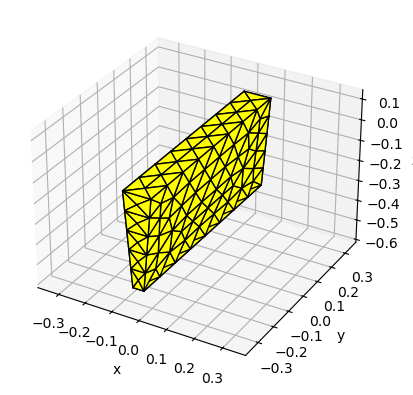

In [46]:
# platform is a rectangle with cg at -0.46 and 1.44 m long, 0.76 m wide
flapThicknessBottom = 0.04
flapThicknessTop = 0.1
flapWidth = 0.76
flapHeight = 0.45
flapCG = [0, 0, -0.36] # from water surface/origin

with pygmsh.geo.Geometry() as geom:
    flap = geom.add_polygon(
            [[-flapThicknessBottom/2, -flapWidth/2, -0.46],
            [flapThicknessBottom/2, -flapWidth/2, -0.46],
            [flapThicknessTop/2, -flapWidth/2, -.01],
            [-flapThicknessTop/2, -flapWidth/2, -.01]],mesh_size=0.1)
    geom.extrude(flap,[0,flapWidth,0])
    flapMesh = geom.generate_mesh()

# define the floating body
flap = cpt.FloatingBody(mesh=flapMesh, name=f'flap', center_of_mass=flapCG)
flap.rotation_center = flapCG # define rotation about cg and M4E will handle transformaiton
flap.add_translation_dof(name='Surge')
flap.add_translation_dof(name='Heave')
flap.add_rotation_dof(name='Pitch')
flap = flap.immersed_part()
rigid_inertia_matrix_xr = xr.DataArray(data=np.asarray((np.diag([0.5*(.05*.76*.56)*1000,0.5*(.05*.76*.56)*1000,1.19]))),
                            dims=['influenced_dof', 'radiating_dof'],
                            coords={'influenced_dof': list(flap.dofs),
                                    'radiating_dof': list(flap.dofs)},
                            name="inertia_matrix")

# Set FloatingBody inertia matrix
flap.inertia_matrix = rigid_inertia_matrix_xr
flap.hydrostatic_stiffness = flap.compute_hydrostatic_stiffness(rho=1025)

flap.show_matplotlib()

#%% Load or run BEM
fname = 'bem_oneFlap.nc'
if os.path.exists(fname):
    bem_data = wot.read_netcdf(fname)
else:
    bem_data = wot.run_bem(flap, freq, wave_dirs=0)
    bem_data['radiating_dof'] = bem_data['radiating_dof'].astype(str)
    bem_data['influenced_dof'] = bem_data['influenced_dof'].astype(str)
    wot.write_netcdf(fname, bem_data)

In [47]:
########################################
# Define the multibody system
MBDsys      = MbdSystem.from_example(ex)
mainNumVars = MBDsys.ic # For now

#%% Linearization
# Define the equilibrium position
q0 = mainNumVars[:len(MBDsys.Q)]

# Obtain the mass and inertia values from all_bodies
mass_and_inertia = np.diag(flap.inertia_matrix.values)
m0 = mass_and_inertia[::3]
J0 = mass_and_inertia[2::3]
ex.m0 = m0 # Updating it here just in case
ex.J0 = J0

# Instantiate the linearized MBD system
LinManager = LinearizationManager(MBDsys, q0, mainNumVars, m0, J0)

# Instanciate and register hydrodynamics adapter
hydroAdapter = HydroLinearMCKF(
        MBDsys,
        (mainNumVars, ex.m0, ex.J0),
        is_2D=True,
        data=bem_data
        )

LinManager.register(hydroAdapter)

# Instantiate the total linearized system with attributes M,C,K,F
LinSystem = LinManager.linearize_total(mainNumVars)

# print('Total linearized mass matrix in joint coordinates:')
# print(LinSystem.M)
# print('Total linearized damping matrix in joint coordinates:')
# print(LinSystem.C)
# print('Total linearized stiffness matrix in joint coordinates:')
# print(LinSystem.K)
# print('Total linearized force vector in joint coordinates:')
# print(LinSystem.F)
# TODO: convert from unit force (capytaine coefficient) to excitation force
# whenever we integrate manually. WecOptTool does it internally.


Problem initialization finished in:		 0.000 seconds
All branches in the graph:
R and RD matrices calculation finished in:	 0.033 seconds
Symbolic EOM computation finished in:		 0.003 seconds
Compiling EOM expressions finished in:		 0.035 seconds


INFO:capytaine.io.meshio:Stored 312 triangle faces as quadrilaterals
INFO:capytaine.bodies.bodies:New floating body: FloatingBody(mesh=Mesh(..., name="mesh_from_meshio_11"), lid_mesh=None, dofs={}, center_of_mass=[ 0.    0.   -0.36], name="flap").
INFO:capytaine.bodies.bodies:Clipping flap with respect to Plane(normal=[0. 0. 1.], point=[0. 0. 0.])
INFO:capytaine.meshes.clipper:Clipping mesh_from_meshio_11 by Plane(normal=[0. 0. 1.], point=[0. 0. 0.]): no action.


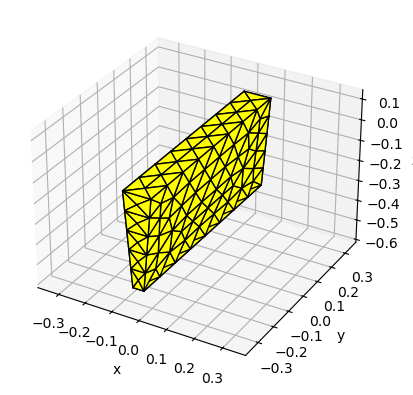

In [ ]:
# run Capytaine about the hinge
# platform is a rectangle with cg at -0.46 and 1.44 m long, 0.76 m wide
flapThicknessBottom = 0.04
flapThicknessTop = 0.1
flapWidth = 0.76
flapHeight = 0.45
flapCG = [0, 0, -0.36] # from water surface/origin
hingePoint = [0, 0, -0.5]

with pygmsh.geo.Geometry() as geom:
    flap_hinge = geom.add_polygon(
            [[-flapThicknessBottom/2, -flapWidth/2, -0.46],
            [flapThicknessBottom/2, -flapWidth/2, -0.46],
            [flapThicknessTop/2, -flapWidth/2, -.01],
            [-flapThicknessTop/2, -flapWidth/2, -.01]],mesh_size=0.1)
    geom.extrude(flap_hinge,[0,flapWidth,0])
    flapMesh = geom.generate_mesh()

# define the floating body
flap_hinge = cpt.FloatingBody(mesh=flapMesh, name=f'flap', center_of_mass=flapCG)
flap_hinge.rotation_center = hingePoint # define rotation about cg and M4E will handle transformaiton
#flap_hinge.add_translation_dof(name='Surge')
#flap_hinge.add_translation_dof(name='Heave')
axisHinge = cpt.Axis(vector=(0, 1, 0), point=hingePoint)
flap_hinge.add_rotation_dof(axis=axisHinge, name='Pitch_hinge')
flap_hinge = flap_hinge.immersed_part()
rigid_inertia_matrix_xr = xr.DataArray(data=np.asarray((np.diag([1.19 + 0.5*(.05*.76*.56)*1000*(0.14)**2]))),
                            dims=['influenced_dof', 'radiating_dof'],
                            coords={'influenced_dof': list(flap_hinge.dofs),
                                    'radiating_dof': list(flap_hinge.dofs)},
                            name="inertia_matrix")

# Set FloatingBody inertia matrix
flap_hinge.inertia_matrix = rigid_inertia_matrix_xr
flap_hinge.hydrostatic_stiffness = flap_hinge.compute_hydrostatic_stiffness(rho=1025)

flap_hinge.show_matplotlib()

#%% Load or run BEM
fname = 'bem_oneFlap_hinge.nc'
if os.path.exists(fname):
    bem_data_hinge = wot.read_netcdf(fname)
else:
    bem_data_hinge = wot.run_bem(flap_hinge, freq, wave_dirs=0)
    bem_data_hinge['radiating_dof'] = bem_data_hinge['radiating_dof'].astype(str)
    bem_data_hinge['influenced_dof'] = bem_data_hinge['influenced_dof'].astype(str)
    wot.write_netcdf(fname, bem_data_hinge)

In [49]:
print(bem_data['hydrostatic_stiffness'])
#print(LinManager.R0.T)
#print(LinManager.dxdq0_func(*mainNumVars))

for name, ad in LinManager.adapters.items():
    M, C, K, F = ad.linearized_MCKF(mainNumVars)

Kh = LinManager.R0.T @ K @ LinManager.dxdq0_func(*mainNumVars)
print(Kh)

<xarray.DataArray 'hydrostatic_stiffness' (influenced_dof: 3, radiating_dof: 3)> Size: 72B
array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00, -1.39544626e-13,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  3.80094641e+01]])
Coordinates:
  * influenced_dof  (influenced_dof) <U5 60B 'Surge' 'Heave' 'Pitch'
  * radiating_dof   (radiating_dof) <U5 60B 'Surge' 'Heave' 'Pitch'
    g               float64 8B 9.81
    rho             float64 8B 1.025e+03
    body_name       <U21 84B 'copy_of_flap_immersed'
    water_depth     float64 8B inf
    forward_speed   float64 8B 0.0
[[38.00946406]]


[[38.00946406]]
<xarray.DataArray 'hydrostatic_stiffness' (influenced_dof: 3, radiating_dof: 3)> Size: 72B
array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00, -1.39544626e-13,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  3.80094641e+01]])
Coordinates:
  * influenced_dof  (influenced_dof) <U5 60B 'Surge' 'Heave' 'Pitch'
  * radiating_dof   (radiating_dof) <U5 60B 'Surge' 'Heave' 'Pitch'
    g               float64 8B 9.81
    rho             float64 8B 1.025e+03
    body_name       <U21 84B 'copy_of_flap_immersed'
    water_depth     float64 8B inf
    forward_speed   float64 8B 0.0
<xarray.DataArray 'hydrostatic_stiffness' (influenced_dof: 1, radiating_dof: 1)> Size: 8B
array([[71.48122099]])
Coordinates:
  * influenced_dof  (influenced_dof) <U11 44B 'Pitch_hinge'
  * radiating_dof   (radiating_dof) <U11 44B 'Pitch_hinge'
    g               float64 8B 9.81
    rho             float64 8B 1.025e+03
    body_name       <U21 84B 'copy_of_fl

Text(0, 0.5, 'total inertia (kg*m^2)')

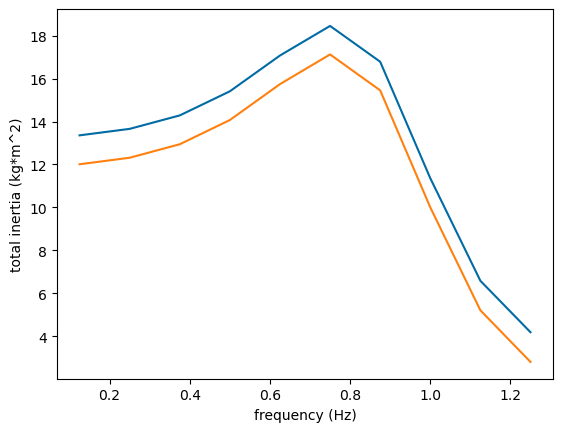

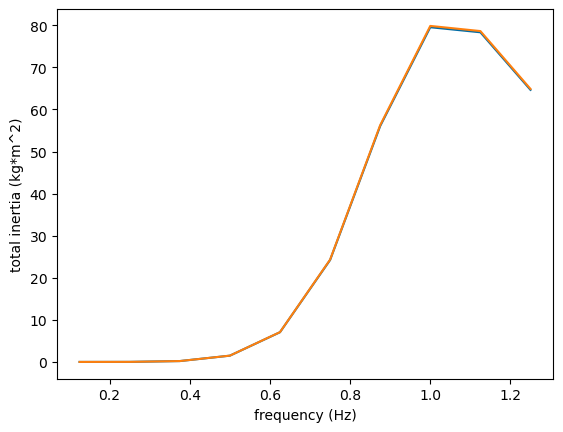

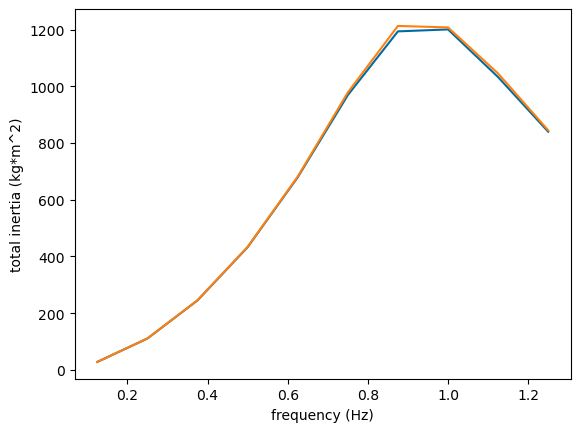

In [50]:
# Extract linearized matrices
M = LinSystem.M
C = LinSystem.C
K = LinSystem.K
F = LinSystem.F

print(K)
print(bem_data['hydrostatic_stiffness'])
print(bem_data_hinge['hydrostatic_stiffness'])

plt.figure()
plt.plot(freq,np.squeeze(M))
plt.plot(freq,np.squeeze(bem_data_hinge['added_mass']))
plt.xlabel('frequency (Hz)')
plt.ylabel('total inertia (kg*m^2)')

plt.figure()
plt.plot(freq,np.squeeze(C))
plt.plot(freq,np.squeeze(bem_data_hinge['radiation_damping']))
plt.xlabel('frequency (Hz)')
plt.ylabel('total inertia (kg*m^2)')

plt.figure()
plt.plot(freq,np.squeeze(abs(F)))
plt.plot(freq,np.squeeze(abs(bem_data_hinge['excitation_force'])))
plt.xlabel('frequency (Hz)')
plt.ylabel('total inertia (kg*m^2)')


INFO:wecopttool.core:Solving pseudo-spectral control problem for realization number 0.
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [2.22e-02, nan, 0.00e+00]
INFO:wecopttool.core:Optimization terminated successfully    (Exit mode 0)


Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.0
            Iterations: 1
            Function evaluations: 2
            Gradient evaluations: 1


c:\Users\jtgrasb\AppData\Local\anaconda3\envs\wot_dev\Lib\site-packages\wecopttool\core.py:967: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'omega' ('omega',) The recommendation is to set join explicitly for this case.
  results_fd = xr.merge([fd_state, fd_forces, wave])
c:\Users\jtgrasb\AppData\Local\anaconda3\envs\wot_dev\Lib\site-packages\wecopttool\core.py:967: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  results_fd 

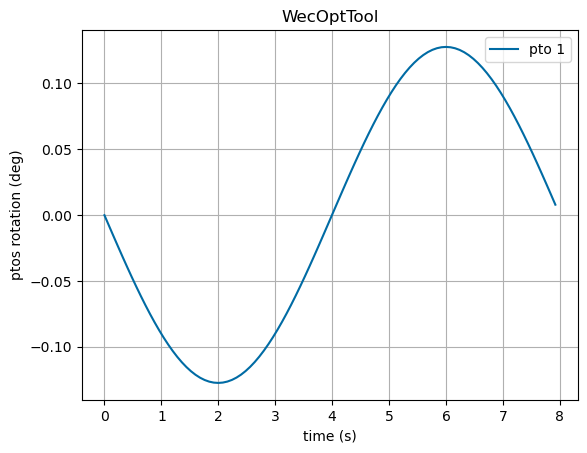

In [51]:
#%% Define the impedance matrix
# Define the excitation omegas
omega = freq*2*np.pi


# add forces to stabilize system
#mooring_stiffness = np.diag([3*1e5, 6e4, 5e4, 0, 0, 0, 0, 0, 0])
#mooring_stiffness = R0.T @ mooring_stiffness @ dxdq0

#mooring_damping = np.diag([3*1e4, 5e4, 5e5, 0, 0, 0, 0, 0, 0])
#mooring_damping = R0.T @ mooring_damping @ R0


#########################################
# Solve using wec opt tool

def f_mooring(wec, x_wec, x_opt, wave, nsubsteps=1):
    pos = wec.vec_to_dofmat(x_wec)
    vel = jnp.dot(wec.derivative_mat,pos)
 
    time_matrix = wec.time_mat_nsubsteps(nsubsteps)
    mooring = -pos @ mooring_stiffness - vel @ mooring_damping
    print(np.shape(mooring))
    #print(mooring)
    mooring_force = jnp.dot(time_matrix,mooring)
    #print(mooring_force)
    return mooring_force

# WecOptTool does not take gravity into account and assumes equilibrium so no pretension needed

f_add = {} #{'mooring': f_mooring}

#%% Define and solve the WOT object
wec = wot.WEC.from_bem(
    bem_data_hinge,
    constraints=None,
    friction=None,
    f_add=f_add,
)

# Objective function
obj_fun = lambda wec, x_wec, x_opt, waves : 0
nstate_opt = 0

# Solve
scale_x_wec = 1e1
scale_x_opt = 1e-3
scale_obj = 1e-2

results = wec.solve(
    waves,
    obj_fun,
    nstate_opt,
    scale_x_wec=scale_x_wec,
    scale_x_opt=scale_x_opt,
    scale_obj=scale_obj,
)

#%% Plot results
nsubsteps = 5
wec_fdom, wec_tdom = wec.post_process(wec, results, waves, nsubsteps=nsubsteps)
# wec_tdom['wave_elev'].plot()

# plt.figure()
# plt.plot(wec_tdom['time'],wec_tdom.pos[0,0,:])
# plt.plot(wec_tdom['time'],wec_tdom.pos[0,1,:])
# plt.plot(wec_tdom['time'],wec_tdom.pos[0,2,:]*180/np.pi)
# plt.xlabel('time (s)')
# plt.ylabel('platform position (m or deg)')
# plt.legend(['surge','heave','pitch'])
# plt.grid()


plt.figure()
plt.plot(wec_tdom['time'],wec_tdom.pos[0,0,:]*180/np.pi)
#plt.plot(wec_tdom['time'],wec_tdom.pos[0,0,:]*180/np.pi)
plt.xlabel('time (s)')
plt.ylabel('ptos rotation (deg)')
plt.legend(['pto 1'])
plt.title('WecOptTool')
plt.grid()
plt.show()

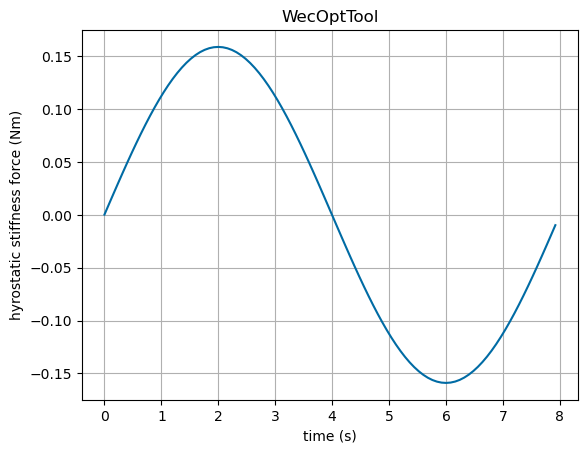

In [57]:

plt.figure()
plt.plot(wec_tdom['time'],np.squeeze(wec_tdom['force'].sel(type='hydrostatics')))
#plt.plot(wec_tdom['time'],wec_tdom.pos[0,0,:]*180/np.pi)
plt.xlabel('time (s)')
plt.ylabel('hyrostatic stiffness force (Nm)')
#plt.legend(['pto 1'])
plt.title('WecOptTool')
plt.grid()
plt.show()